# Leave-k-out validation (Phases A + D)

Quantitative comparison of inverse-Ising models against three naive baselines (marginal usage, co-occurrence weight, PPMI weight) on a tournament-strided held-out test set. For each test team and each $k \in \{1, 2, 3\}$, hold out $k$ random species, score every candidate completion under each model, and measure top-K hit rate + mean reciprocal rank.

Two Ising models are compared head-to-head:

- **Ising species** (Phase 2): PL fit on the species-only vocab — the model that runs in `app.py:load_model_phase2`.
- **Ising item-pair** (Phase 3): PL fit on `(species, item)` pair vocab — the model that runs in `app.py:load_model_phase3`. Restores held-item forme distinctions that the species-only vocab collapses. Evaluation is at **species granularity** for fair cross-model comparison: the item-pair model's species score is $\sum_i P((\text{species}, i) \text{ in team})$ (mutually exclusive events under the uniqueness constraint, so this is exact under the model — though MF computes it approximately).

**Train/test split**: tournaments at indices $[0, 10, 20, \ldots]$ (every 10th, newest-first) form the test set; remaining 90% form the train set. Strided split keeps both halves spanning the full corpus time range — decouples "model is bad" from "meta has shifted."

**Methodology notes**:
- Vocab is built on the **full corpus** for index consistency between train and test (test mons need vocab indices to be ranked). Cutoff matches `PHASE2_MIN_TEAM_COUNT = 5` (species or pair appears in at least 5 teams).
- Model parameters $(J, h)$ are fit on **train only** — no test-set leakage in the fit.
- Model marginals at inference use mean-field iteration. Ranking-preserving without the team-size constraint, since the constraint adds a global Lagrange multiplier identical across candidates; fast (sub-second per test instance, vs minutes for full PT).

In [1]:
from __future__ import annotations
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

import helpers
import limitless_ingest

tournaments = limitless_ingest.ingest()
print(f"tournaments:           {len(tournaments)}")
print(f"total team-appearances: {sum(len(t.teams) for t in tournaments)}")

tournaments:           93
total team-appearances: 11028


## Train/test split

Tournaments are already in date order (newest-first) from `limitless_ingest`. Strided 90/10: test indices = `[0, 10, 20, ...]`; train = the rest. Disjoint at the tournament level, so no team in train appears in test.

Each set is kept in two forms: `_full` (frozensets of `(species, item)` tuples, for Phase 3) and species-only (frozensets of species names, for Phase 2 + the baselines).

In [2]:
TEST_STRIDE = 5
test_tournaments = [t for i, t in enumerate(tournaments) if i % TEST_STRIDE == 0 and len(t.teams) < 1000]
train_tournaments = [t for i, t in enumerate(tournaments) if i % TEST_STRIDE != 0 or len(t.teams) >= 1000]

train_teams_full = limitless_ingest.all_teams(train_tournaments)
test_teams_full = limitless_ingest.all_teams(test_tournaments)
train_teams = limitless_ingest.species_only_teams(train_teams_full)
test_teams = limitless_ingest.species_only_teams(test_teams_full)
n_total = len(train_teams) + len(test_teams)

print(f"train tournaments: {len(train_tournaments):>3}   teams: {len(train_teams):>5}   ({len(train_teams)/n_total:.1%})")
print(f"test tournaments:  {len(test_tournaments):>3}   teams: {len(test_teams):>5}   ({len(test_teams)/n_total:.1%})")

train tournaments:  74   teams:  9752   (88.4%)
test tournaments:   19   teams:  1276   (11.6%)


## Species-vocab matrices (Phase 2 model + baselines)

Species vocab from the full corpus; marginal $m$, co-occurrence $C$, and PPMI built from train teams only.

In [3]:
MIN_TEAM_COUNT = 5

species_counts = Counter(name for team in (train_teams + test_teams) for name in team)
vocab = sorted(name for name, c in species_counts.items() if c >= MIN_TEAM_COUNT)
name_to_idx = {name: i for i, name in enumerate(vocab)}
V = len(vocab)
print(f"species vocab size: {V} (>= {MIN_TEAM_COUNT} appearances in full corpus)")


def teams_to_matrix(teams, name_to_idx, V):
    X = np.zeros((len(teams), V), dtype=np.int8)
    for ti, team in enumerate(teams):
        for name in team:
            j = name_to_idx.get(name)
            if j is not None:
                X[ti, j] = 1
    return X


X_train = teams_to_matrix(train_teams, name_to_idx, V)

m_train = X_train.mean(axis=0)
C_train = (X_train.astype(np.int64).T @ X_train.astype(np.int64)).astype(np.float64)
np.fill_diagonal(C_train, 0.0)
PPMI_train = helpers.build_ppmi(C_train)

print(f"m_train range:    [{m_train.min():.4f}, {m_train.max():.4f}]")
print(f"C_train off-diag: max = {int(C_train.max())}, nnz = {int((C_train > 0).sum())}")

species vocab size: 195 (>= 5 appearances in full corpus)
m_train range:    [0.0004, 0.4768]
C_train off-diag: max = 1947, nnz = 14572


## Phase 2 PL fit (species vocab)

Same per-spin logistic regression as `inverse_ising_phase2.ipynb`, run on the train-team species matrix. L2 with `C = 0.1` to match the app's current default.

In [4]:
PHASE2_LR_C = 0.1

J_asym = np.zeros((V, V), dtype=np.float64)
h = np.zeros(V, dtype=np.float64)
X_train_int = X_train.astype(np.int32)

for i in range(V):
    y = X_train_int[:, i]
    if y.sum() < 2 or (1 - y).sum() < 2:
        continue
    mask = np.ones(V, dtype=bool)
    mask[i] = False
    lr = LogisticRegression(penalty="l2", C=PHASE2_LR_C, solver="lbfgs", max_iter=1000)
    lr.fit(X_train_int[:, mask], y)
    h[i] = lr.intercept_[0]
    J_asym[i, mask] = lr.coef_[0]
    if (i + 1) % 25 == 0:
        print(f"  fit {i + 1} / {V}")

J = 0.5 * (J_asym + J_asym.T)
np.fill_diagonal(J, 0.0)

iu = np.triu_indices(V, 1)
print(f"\nJ off-diagonal range: [{J[iu].min():+.3f}, {J[iu].max():+.3f}]")
print(f"h range:              [{h.min():+.3f}, {h.max():+.3f}]")

  fit 25 / 195
  fit 50 / 195
  fit 75 / 195
  fit 100 / 195
  fit 125 / 195
  fit 150 / 195
  fit 175 / 195

J off-diagonal range: [-3.163, +2.764]
h range:              [-7.456, +5.539]


## Phase 3 PL fit ((species, item) pair vocab)

Pair vocab built from `train_teams_full + test_teams_full` with the same `MIN_TEAM_COUNT = 5` cutoff (now applied to `(species, item)` pairs, so the vocab is larger). The fit is the same PL machinery, just on a wider feature matrix. `solver="lbfgs"` is fine at this scale; if V_pair grows past ~2000, switch to `liblinear` on sparse X.

The `species_to_pair_idxs` map lets the eval loop project pair marginals down to species marginals for fair comparison against the species-only model: $P(\text{species in team}) = \sum_i P((\text{species}, i) \text{ in team})$ (item slots are mutually exclusive under the Phase 3 uniqueness constraint, so the sum is exact under the model).

In [5]:
pair_counts = Counter(pair for team in (train_teams_full + test_teams_full) for pair in team)
pair_vocab = sorted(
    (p for p, c in pair_counts.items() if c >= MIN_TEAM_COUNT),
    key=lambda p: (p[0], p[1] or ""),
)
pair_to_idx = {p: i for i, p in enumerate(pair_vocab)}
V_pair = len(pair_vocab)
print(f"pair vocab size: {V_pair} ((species, item) pairs with >= {MIN_TEAM_COUNT} appearances)")

# Species -> list of pair indices for that species (one per item variant)
species_to_pair_idxs: dict[str, list[int]] = {}
for i, (species, _) in enumerate(pair_vocab):
    species_to_pair_idxs.setdefault(species, []).append(i)

X_train_pair = np.zeros((len(train_teams_full), V_pair), dtype=np.int8)
for ti, team in enumerate(train_teams_full):
    for pair in team:
        j = pair_to_idx.get(pair)
        if j is not None:
            X_train_pair[ti, j] = 1

J_pair_asym = np.zeros((V_pair, V_pair), dtype=np.float64)
h_pair = np.zeros(V_pair, dtype=np.float64)
X_train_pair_int = X_train_pair.astype(np.int32)

for i in range(V_pair):
    y = X_train_pair_int[:, i]
    if y.sum() < 2 or (1 - y).sum() < 2:
        continue
    mask = np.ones(V_pair, dtype=bool)
    mask[i] = False
    lr = LogisticRegression(penalty="l2", C=PHASE2_LR_C, solver="lbfgs", max_iter=1000)
    lr.fit(X_train_pair_int[:, mask], y)
    h_pair[i] = lr.intercept_[0]
    J_pair_asym[i, mask] = lr.coef_[0]
    if (i + 1) % 100 == 0:
        print(f"  fit {i + 1} / {V_pair}")

J_pair = 0.5 * (J_pair_asym + J_pair_asym.T)
np.fill_diagonal(J_pair, 0.0)

iu_pair = np.triu_indices(V_pair, 1)
print(f"\npair J off-diagonal range: [{J_pair[iu_pair].min():+.3f}, {J_pair[iu_pair].max():+.3f}]")
print(f"pair h range:              [{h_pair.min():+.3f}, {h_pair.max():+.3f}]")

pair vocab size: 606 ((species, item) pairs with >= 5 appearances)
  fit 100 / 606
  fit 200 / 606
  fit 300 / 606
  fit 400 / 606
  fit 500 / 606
  fit 600 / 606

pair J off-diagonal range: [-3.245, +3.254]
pair h range:              [-8.288, +0.224]


## Candidate scoring functions

All scorers return a length-$V$ (species) score array. Higher = more likely completion. Held-in species are masked out at ranking time.

- **Marginal**: $\text{score}_i = m_i$. Ignores held-in entirely.
- **Co-occurrence**: $\sum_{j \in \text{held-in}} C_{ij}$. Raw count-weighted summation.
- **PPMI**: $\sum_{j \in \text{held-in}} \text{PPMI}_{ij}$. Normalized but theoretically the wrong metric for this task (measures surprise, not completion probability — see CLAUDE.md).
- **Ising species (MF)**: damped mean-field on the species $(J, h)$, held-in species clamped to 1.
- **Ising item-pair (MF)**: damped mean-field on the pair $(J_{\text{pair}}, h_{\text{pair}})$ with held-in **pairs** clamped to 1 (using the test team's actual items), then project to species marginals via the mutual-exclusion sum.

In [6]:
def score_marginal(held_in_species_idx, *, m):
    return m.copy()


def score_cooccurrence(held_in_species_idx, *, C):
    return C[:, list(held_in_species_idx)].sum(axis=1)


def score_ppmi(held_in_species_idx, *, PPMI):
    return PPMI[:, list(held_in_species_idx)].sum(axis=1)


def score_ising_meanfield(held_in_idx, *, J, h, n_iters=200, tol=1e-4, damp=0.5):
    """Mean-field marginals with held-in indices clamped to 1.
    Generic over vocab -- used for both species and pair vocabs.
    Returns length-V marginal array (V = len(h))."""
    V_local = len(h)
    fixed_mask = np.zeros(V_local, dtype=bool)
    fixed_mask[list(held_in_idx)] = True
    m_local = 1.0 / (1.0 + np.exp(-h))
    m_local[fixed_mask] = 1.0
    for _ in range(n_iters):
        m_new = 1.0 / (1.0 + np.exp(-(h + J @ m_local)))
        m_new[fixed_mask] = 1.0
        delta = float(np.max(np.abs(m_new[~fixed_mask] - m_local[~fixed_mask])))
        m_local = damp * m_new + (1.0 - damp) * m_local
        m_local[fixed_mask] = 1.0
        if delta < tol:
            break
    return m_local


def score_ising_phase3(
    held_in_pair_idx, *,
    J_pair, h_pair, species_to_pair_idxs, name_to_idx, V_species,
):
    """Phase 3 species score: pair-MF marginals, summed within each species.
    
    held_in_pair_idx are indices in pair_vocab (not species vocab) — the
    test team's actual (species, item) pairs for held-in slots. Output is
    length-V_species; species not in pair_vocab get score 0."""
    pair_marginals = score_ising_meanfield(held_in_pair_idx, J=J_pair, h=h_pair)
    species_scores = np.zeros(V_species)
    for species, idxs in species_to_pair_idxs.items():
        s_idx = name_to_idx.get(species)
        if s_idx is None:
            continue
        species_scores[s_idx] = sum(pair_marginals[i] for i in idxs)
    return species_scores

## Held-out evaluation loop

Filter test teams to those with all members in **both** vocabs (species + pair) — keeps evaluation fair across all 5 models, since any model that can't represent a team's species or item shouldn't be penalized for it.

For each in-vocab test team and each $k \in \{1, 2, 3\}$, sample one random held-out subset of size $k$. The species-only baselines see species indices for held-in; Phase 3 sees pair indices (with actual items). All scorers return scores at species granularity. Rank held-out species in each score list, after masking out held-in species.

In [7]:
SEED = 42
K_VALUES = [1, 2, 3]
TOP_K_THRESHOLDS = [1, 5, 10, 20]

rng = np.random.default_rng(SEED)

in_vocab_test = []
for team in test_teams_full:
    if len(team) != 6:
        continue
    species_set = {s for s, _ in team}
    if len(species_set) != 6:
        continue
    if not all(s in name_to_idx for s in species_set):
        continue
    if not all(p in pair_to_idx for p in team):
        continue
    in_vocab_test.append(team)
print(f"in-vocab test teams: {len(in_vocab_test)} / {len(test_teams_full)}")

scorers_species_in = {
    "marginal":         lambda held_in: score_marginal(held_in, m=m_train),
    "co-occurrence":    lambda held_in: score_cooccurrence(held_in, C=C_train),
    "PPMI":             lambda held_in: score_ppmi(held_in, PPMI=PPMI_train),
    "Ising species":    lambda held_in: score_ising_meanfield(held_in, J=J, h=h),
}
scorers_pair_in = {
    "Ising item-pair":  lambda held_in: score_ising_phase3(
        held_in, J_pair=J_pair, h_pair=h_pair,
        species_to_pair_idxs=species_to_pair_idxs,
        name_to_idx=name_to_idx, V_species=V,
    ),
}
all_models = list(scorers_species_in) + list(scorers_pair_in)

results = {name: {k: [] for k in K_VALUES} for name in all_models}

for team in in_vocab_test:
    members = sorted(team, key=lambda p: p[0])  # deterministic order by species
    species_idxs = np.array([name_to_idx[s] for s, _ in members])
    pair_idxs = np.array([pair_to_idx[p] for p in members])
    for k in K_VALUES:
        held_out_pos = rng.choice(6, size=k, replace=False)
        held_in_pos = np.delete(np.arange(6), held_out_pos)
        held_out_species_idx = species_idxs[held_out_pos]
        held_in_species_idx = species_idxs[held_in_pos]
        held_in_pair_idx = pair_idxs[held_in_pos]

        for name, scorer in scorers_species_in.items():
            scores = scorer(held_in_species_idx).astype(np.float64).copy()
            scores[held_in_species_idx] = -np.inf
            order = np.argsort(-scores)
            rank_of = np.empty(V, dtype=np.int64)
            rank_of[order] = np.arange(1, V + 1)
            results[name][k].append(rank_of[held_out_species_idx])

        for name, scorer in scorers_pair_in.items():
            scores = scorer(held_in_pair_idx).astype(np.float64).copy()
            scores[held_in_species_idx] = -np.inf
            order = np.argsort(-scores)
            rank_of = np.empty(V, dtype=np.int64)
            rank_of[order] = np.arange(1, V + 1)
            results[name][k].append(rank_of[held_out_species_idx])

for name in all_models:
    for k in K_VALUES:
        results[name][k] = np.array(results[name][k])

print(f"\nevaluated {len(in_vocab_test)} teams x {len(K_VALUES)} k values x {len(all_models)} models")

in-vocab test teams: 1162 / 1276

evaluated 1162 teams x 3 k values x 5 models


## Metrics table

Top-K hit rate at $K \in \{1, 5, 10, 20\}$ and mean reciprocal rank (MRR), faceted by $k$.

In [8]:
def hit_rate_at_k(ranks, K):
    return float((ranks <= K).mean())


def mrr(ranks):
    return float((1.0 / ranks).mean())


header = f"{'model':<18} {'k':>2}  {'MRR':>6}  " + "  ".join(f"top-{K:>2}" for K in TOP_K_THRESHOLDS)
print(header)
print("-" * len(header))
for name in all_models:
    for k in K_VALUES:
        ranks = results[name][k]
        row = f"{name:<18} {k:>2}  {mrr(ranks):>6.3f}  "
        row += "  ".join(f"{hit_rate_at_k(ranks, K):>6.1%}" for K in TOP_K_THRESHOLDS)
        print(row)
    print()

model               k     MRR  top- 1  top- 5  top-10  top-20
-------------------------------------------------------------
marginal            1   0.276   13.2%   43.3%   56.9%   75.4%
marginal            2   0.250   11.0%   41.2%   55.3%   75.3%
marginal            3   0.242   10.6%   39.8%   54.6%   74.2%

co-occurrence       1   0.354   19.4%   51.4%   67.6%   84.6%
co-occurrence       2   0.318   15.7%   48.6%   67.4%   82.1%
co-occurrence       3   0.299   14.0%   48.0%   65.9%   81.9%

PPMI                1   0.178    8.9%   23.3%   34.9%   49.1%
PPMI                2   0.152    7.0%   20.7%   30.4%   45.9%
PPMI                3   0.124    4.9%   16.4%   26.2%   39.6%

Ising species       1   0.509   36.5%   67.9%   81.9%   90.1%
Ising species       2   0.397   22.5%   59.8%   76.0%   87.8%
Ising species       3   0.336   16.9%   52.9%   70.3%   85.2%

Ising item-pair     1   0.592   47.4%   73.1%   83.5%   90.7%
Ising item-pair     2   0.461   28.1%   67.6%   80.2%   88.8%
Isin

## Visual comparison

Top-K hit rate as a function of $K$, one panel per $k$. The headline comparison is **Ising species vs Ising item-pair** — that's the test of whether the item-pair extension is earning the implementation cost.

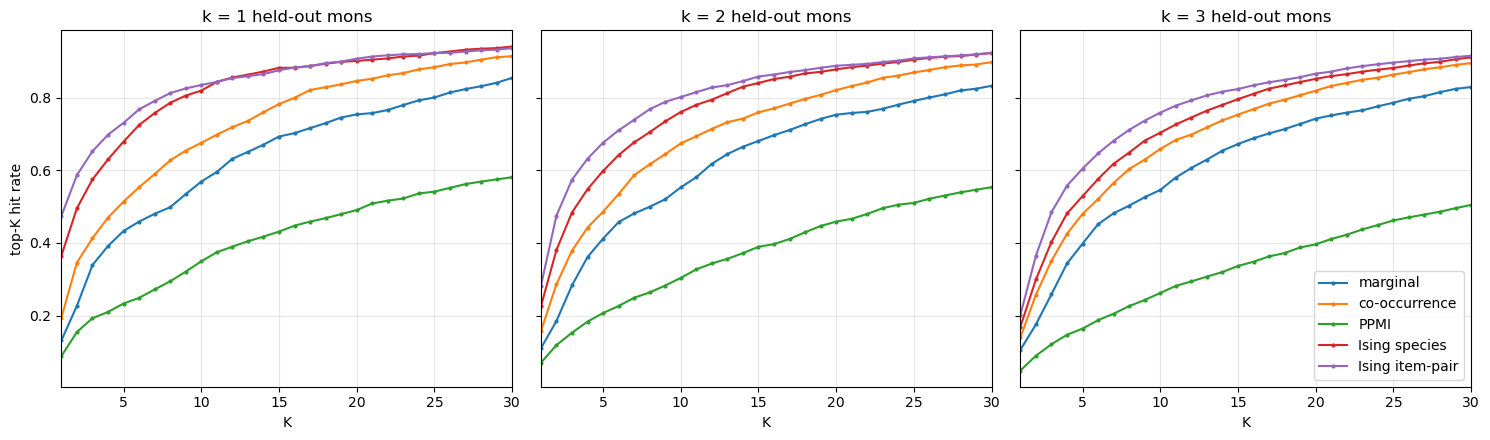

In [9]:
K_RANGE = list(range(1, 31))

fig, axes = plt.subplots(1, len(K_VALUES), figsize=(15, 4.5), sharey=True)
for ax, k in zip(axes, K_VALUES):
    for name in all_models:
        ranks = results[name][k]
        hits = [hit_rate_at_k(ranks, K) for K in K_RANGE]
        ax.plot(K_RANGE, hits, label=name, marker=".", markersize=4)
    ax.set_xlabel("K")
    ax.set_title(f"k = {k} held-out mons")
    ax.grid(alpha=0.3)
    ax.set_xlim(1, K_RANGE[-1])
axes[0].set_ylabel("top-K hit rate")
axes[-1].legend(loc="lower right")
plt.tight_layout()
plt.show()

## Pair-prediction metric (Phase 3 only)

The cross-model evaluation above projects Phase 3's pair predictions down to species granularity so it can compete with the species-only models. That measures one specific question — "does adding item information help species prediction" — but ignores the other thing the item-pair model lets us do: **predict the held-out species AND its item jointly**.

The species-only model literally cannot answer this; there's no way to score a `(species, item)` pair when items aren't features. So this is a Phase-3-vs-Phase-3-baselines comparison: pair-marginal and pair-co-occurrence are the natural counterparts to the species-level marginal/co-occurrence baselines (PPMI omitted — clearly the wrong baseline per prior results).

Held-out pairs are sampled with the same `SEED` and same positions as the species evaluation, but ranked against the full pair vocab with two masks applied:
- Held-in **species** are masked out (no two Charizards).
- Held-in **items** are masked out (no two Choice Specs).

The held-out pair, by team construction, satisfies both — so it's a valid candidate. The interesting numbers here are top-1 / MRR: how often can the model identify the *specific* `(species, item)` build held out, not just the species. Top-1 hit rate is upper-bounded by what the species model gets *times* the probability of guessing the right item conditional on the right species, so absolute numbers will be substantially lower than the species table; the model-vs-baseline gap is what matters.

In [10]:
# Pair-level training matrices for the pair-marginal / pair-co-occurrence baselines.
m_train_pair = X_train_pair.mean(axis=0)
C_train_pair = (X_train_pair_int.T @ X_train_pair_int).astype(np.float64)
np.fill_diagonal(C_train_pair, 0.0)

# Lookup arrays for fast uniqueness masking inside the eval loop.
pair_species_idx = np.array(
    [name_to_idx.get(sp, -1) for sp, _ in pair_vocab], dtype=np.int32
)
all_items_sorted = sorted({it for _, it in pair_vocab if it is not None})
item_to_id = {it: i for i, it in enumerate(all_items_sorted)}
pair_item_id = np.array(
    [item_to_id.get(it, -1) for _, it in pair_vocab], dtype=np.int32
)

print(f"pair vocab size:       {V_pair}")
print(f"distinct items:        {len(all_items_sorted)}")
print(f"m_train_pair range:    [{m_train_pair.min():.4f}, {m_train_pair.max():.4f}]")
print(f"C_train_pair off-diag: max = {int(C_train_pair.max())}, nnz = {int((C_train_pair > 0).sum())}")

pair vocab size:       606
distinct items:        121
m_train_pair range:    [0.0002, 0.3852]
C_train_pair off-diag: max = 933, nnz = 41436


In [11]:
def score_pair_marginal(held_in_pair_idx, *, m_pair):
    return m_pair.copy()


def score_pair_cooccurrence(held_in_pair_idx, *, C_pair):
    return C_pair[:, list(held_in_pair_idx)].sum(axis=1)


def score_pair_ising_mf(held_in_pair_idx, *, J_pair, h_pair):
    return score_ising_meanfield(held_in_pair_idx, J=J_pair, h=h_pair)

In [12]:
# Restart RNG at same seed so held-out positions match the species evaluation above.
rng_pair = np.random.default_rng(SEED)

pair_scorers = {
    "marginal-pair":      lambda hi: score_pair_marginal(hi, m_pair=m_train_pair),
    "co-occurrence-pair": lambda hi: score_pair_cooccurrence(hi, C_pair=C_train_pair),
    "Ising pair":         lambda hi: score_pair_ising_mf(hi, J_pair=J_pair, h_pair=h_pair),
}

pair_results = {name: {k: [] for k in K_VALUES} for name in pair_scorers}

for team in in_vocab_test:
    members = sorted(team, key=lambda p: p[0])
    pair_idxs = np.array([pair_to_idx[p] for p in members])

    for k in K_VALUES:
        held_out_pos = rng_pair.choice(6, size=k, replace=False)
        held_in_pos = np.delete(np.arange(6), held_out_pos)
        held_in_pair_idx = pair_idxs[held_in_pos]
        held_out_pair_idx = pair_idxs[held_out_pos]

        # Uniqueness mask: any candidate pair sharing a species or item with a
        # held-in pair is invalid. Held-in pairs are masked by the species sweep.
        held_in_species_ids = pair_species_idx[held_in_pair_idx]
        held_in_item_ids = pair_item_id[held_in_pair_idx]
        held_in_item_ids = held_in_item_ids[held_in_item_ids >= 0]
        invalid_mask = (
            np.isin(pair_species_idx, held_in_species_ids)
            | np.isin(pair_item_id, held_in_item_ids)
        )

        for name, scorer in pair_scorers.items():
            scores = scorer(held_in_pair_idx).astype(np.float64).copy()
            scores[invalid_mask] = -np.inf
            order = np.argsort(-scores)
            rank_of = np.empty(V_pair, dtype=np.int64)
            rank_of[order] = np.arange(1, V_pair + 1)
            pair_results[name][k].append(rank_of[held_out_pair_idx])

for name in pair_scorers:
    for k in K_VALUES:
        pair_results[name][k] = np.array(pair_results[name][k])

print(f"evaluated {len(in_vocab_test)} teams x {len(K_VALUES)} k values x {len(pair_scorers)} pair-level models")

evaluated 1162 teams x 3 k values x 3 pair-level models


In [13]:
header = f"{'model':<22} {'k':>2}  {'MRR':>6}  " + "  ".join(f"top-{K:>2}" for K in TOP_K_THRESHOLDS)
print(header)
print("-" * len(header))
for name in pair_scorers:
    for k in K_VALUES:
        ranks = pair_results[name][k]
        row = f"{name:<22} {k:>2}  {mrr(ranks):>6.3f}  "
        row += "  ".join(f"{hit_rate_at_k(ranks, K):>6.1%}" for K in TOP_K_THRESHOLDS)
        print(row)
    print()

model                   k     MRR  top- 1  top- 5  top-10  top-20
-----------------------------------------------------------------
marginal-pair           1   0.231   13.3%   28.8%   42.7%   63.0%
marginal-pair           2   0.200    9.8%   28.6%   39.8%   57.6%
marginal-pair           3   0.192    9.2%   27.7%   38.3%   55.1%

co-occurrence-pair      1   0.328   18.5%   47.8%   65.1%   77.7%
co-occurrence-pair      2   0.280   13.8%   43.4%   58.5%   73.7%
co-occurrence-pair      3   0.255   11.6%   39.8%   54.7%   71.4%

Ising pair              1   0.526   41.7%   65.6%   76.2%   83.6%
Ising pair              2   0.397   23.7%   58.5%   70.7%   80.6%
Ising pair              3   0.317   16.1%   50.4%   64.5%   76.0%



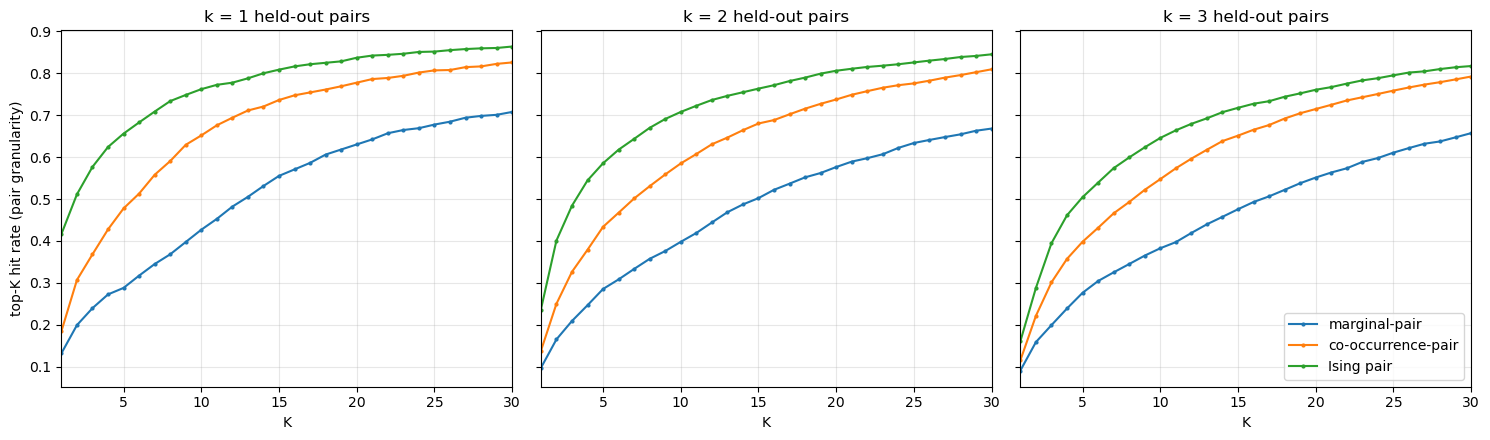

In [14]:
fig, axes = plt.subplots(1, len(K_VALUES), figsize=(15, 4.5), sharey=True)
for ax, k in zip(axes, K_VALUES):
    for name in pair_scorers:
        ranks = pair_results[name][k]
        hits = [hit_rate_at_k(ranks, K) for K in K_RANGE]
        ax.plot(K_RANGE, hits, label=name, marker=".", markersize=4)
    ax.set_xlabel("K")
    ax.set_title(f"k = {k} held-out pairs")
    ax.grid(alpha=0.3)
    ax.set_xlim(1, K_RANGE[-1])
axes[0].set_ylabel("top-K hit rate (pair granularity)")
axes[-1].legend(loc="lower right")
plt.tight_layout()
plt.show()

## Mean-field vs true sampling (pair prediction, ~100 teams)

The eval above uses **mean-field iteration** to compute Ising-pair marginals — fast, deterministic, and ranking-faithful for the team-size constraint, but it factorizes the joint over candidate pairs (each candidate's marginal is computed assuming others are independent). The webapp's PT-MCMC sampler doesn't make that approximation: it samples joint team configurations from the true Ising distribution.

This cell answers the obvious question: **how good is MF actually as a proxy for the sampler?** If the two agree closely (matching top-1 picks, high rank correlation), MF is a faithful and ~100× cheaper replacement and the eval table above is trustworthy. If they diverge — especially at $k \geq 2$ where joint structure between held-out slots matters — the MF eval is undercounting Ising's headline performance.

**Setup**: first 100 in-vocab test teams, same `SEED` so held-out positions match the main pair eval exactly. Four scorers compared on the same problem:

- `marginal-pair` (baseline)
- `co-occurrence-pair` (baseline)
- `Ising pair (MF)` — what the validator uses
- `Ising pair (MCMC)` — single-chain swap-move MCMC at $\text{fw}=1$, $T=1$, 2000 burn-in + 20000 sample steps. Matches the webapp sampler's target distribution at default operating point (no PT needed at $T=1$ — the regime where parallel tempering matters is low $T$ per CLAUDE.md, not here).

Outputs are the usual hit-rate / MRR table for all four, plus a head-to-head MF-vs-MCMC agreement table (top-1 match rate + Spearman rank correlation) which is the cleanest read on "does MF lose anything."

In [15]:
def pair_mcmc_marginal(
    held_in_pair_idx, k_free, *,
    J_pair, h_pair, pair_species_idx, pair_item_id,
    n_burn, n_sample, seed,
):
    """Swap-move MCMC at field_weight=1, T=1 over k_free free slots conditional
    on held_in_pair_idx fixed. Returns length-V marginal frequencies of each pair
    appearing in any free slot across post-burn-in samples.

    This is the same target distribution `app.py:parallel_tempered_mcmc` samples
    from at fw=1, T=1, just with a simpler single-chain implementation since at
    T=1 there's no multi-modality to defeat. Uniqueness (no duplicate species,
    no duplicate item) is enforced by proposal rejection -- matches the app's
    sampler logic.
    """
    rng = np.random.default_rng(seed)
    V = h_pair.shape[0]
    held_in_arr = np.asarray(held_in_pair_idx, dtype=np.int64)

    held_in_sp = {int(s) for s in pair_species_idx[held_in_arr]}
    held_in_it = {int(x) for x in pair_item_id[held_in_arr] if x >= 0}

    # Greedy init: walk shuffled vocab, take first k_free that don't conflict.
    pool = np.arange(V)
    rng.shuffle(pool)
    used_sp, used_it = set(held_in_sp), set(held_in_it)
    free: list[int] = []
    for cand in pool:
        sp = int(pair_species_idx[cand])
        it = int(pair_item_id[cand])
        if sp in used_sp:
            continue
        if it >= 0 and it in used_it:
            continue
        free.append(int(cand))
        used_sp.add(sp)
        if it >= 0:
            used_it.add(it)
        if len(free) == k_free:
            break
    if len(free) < k_free:
        return np.zeros(V)
    free = np.array(free, dtype=np.int64)

    # Maintain incremental species/item membership across the full team for
    # O(1) uniqueness checks inside the chain.
    team_sp = set(held_in_sp)
    team_it = set(held_in_it)
    for f in free:
        team_sp.add(int(pair_species_idx[f]))
        it = int(pair_item_id[f])
        if it >= 0:
            team_it.add(it)

    counts = np.zeros(V, dtype=np.int64)
    n_total = n_burn + n_sample

    for step in range(n_total):
        slot = int(rng.integers(k_free))
        i_out = int(free[slot])
        sp_out = int(pair_species_idx[i_out])
        it_out = int(pair_item_id[i_out])

        i_in = int(rng.integers(V))
        accept = False
        if i_in != i_out:
            sp_in = int(pair_species_idx[i_in])
            it_in = int(pair_item_id[i_in])
            # Uniqueness vs team minus the slot we're swapping out
            sp_ok = (sp_in == sp_out) or (sp_in not in team_sp)
            it_ok = (it_in < 0) or (it_in == it_out) or (it_in not in team_it)
            if sp_ok and it_ok:
                # delta_E = -h(i_in) + h(i_out) - J[i_in, other].sum() + J[i_out, other].sum()
                # where `other` is the rest of the team (held-in + other free slots).
                other_free = np.delete(free, slot)
                team_other = np.concatenate([held_in_arr, other_free])
                delta_E = (
                    -h_pair[i_in] + h_pair[i_out]
                    - J_pair[i_in, team_other].sum()
                    + J_pair[i_out, team_other].sum()
                )
                if delta_E <= 0 or rng.random() < np.exp(-delta_E):
                    accept = True

        if accept:
            free[slot] = i_in
            team_sp.discard(sp_out)
            team_sp.add(int(pair_species_idx[i_in]))
            if it_out >= 0:
                team_it.discard(it_out)
            if pair_item_id[i_in] >= 0:
                team_it.add(int(pair_item_id[i_in]))

        if step >= n_burn:
            for f in free:
                counts[int(f)] += 1

    total = counts.sum()
    return counts.astype(np.float64) / total if total > 0 else counts.astype(np.float64)

In [16]:
# Comparison subset: first COMPARE_N teams from in_vocab_test, with held-out
# positions matching the main pair eval (same SEED, same iteration order, same
# first N teams). Each problem evaluated by all four methods.
COMPARE_N = 100
N_BURN = 2000
N_SAMPLE = 20000

rng_compare = np.random.default_rng(SEED)
compare_teams = in_vocab_test[:COMPARE_N]

compare_methods = ["marginal-pair", "co-occurrence-pair", "Ising pair (MF)", "Ising pair (MCMC)"]
compare_results = {name: {k: [] for k in K_VALUES} for name in compare_methods}

for ti, team in enumerate(compare_teams):
    members = sorted(team, key=lambda p: p[0])
    pair_idxs = np.array([pair_to_idx[p] for p in members])

    for k in K_VALUES:
        held_out_pos = rng_compare.choice(6, size=k, replace=False)
        held_in_pos = np.delete(np.arange(6), held_out_pos)
        held_in_pair_idx = pair_idxs[held_in_pos]
        held_out_pair_idx = pair_idxs[held_out_pos]

        # Shared uniqueness mask (applied identically to all four scorers)
        held_in_species_ids = pair_species_idx[held_in_pair_idx]
        held_in_item_ids = pair_item_id[held_in_pair_idx]
        held_in_item_ids_valid = held_in_item_ids[held_in_item_ids >= 0]
        invalid_mask = (
            np.isin(pair_species_idx, held_in_species_ids)
            | np.isin(pair_item_id, held_in_item_ids_valid)
        )

        # Closed-form scorers
        method_scores = {
            "marginal-pair":      score_pair_marginal(held_in_pair_idx, m_pair=m_train_pair),
            "co-occurrence-pair": score_pair_cooccurrence(held_in_pair_idx, C_pair=C_train_pair),
            "Ising pair (MF)":    score_pair_ising_mf(held_in_pair_idx, J_pair=J_pair, h_pair=h_pair),
        }
        # MCMC scorer: distinct seed per (team, k) so chains are independent
        method_scores["Ising pair (MCMC)"] = pair_mcmc_marginal(
            held_in_pair_idx, k_free=k,
            J_pair=J_pair, h_pair=h_pair,
            pair_species_idx=pair_species_idx, pair_item_id=pair_item_id,
            n_burn=N_BURN, n_sample=N_SAMPLE,
            seed=SEED + ti * 100 + k,
        )

        for name, scores_raw in method_scores.items():
            scores = scores_raw.astype(np.float64).copy()
            scores[invalid_mask] = -np.inf
            order = np.argsort(-scores)
            rank_of = np.empty(V_pair, dtype=np.int64)
            rank_of[order] = np.arange(1, V_pair + 1)
            compare_results[name][k].append(rank_of[held_out_pair_idx])

    if (ti + 1) % 10 == 0:
        print(f"  team {ti + 1} / {COMPARE_N}")

for name in compare_methods:
    for k in K_VALUES:
        compare_results[name][k] = np.array(compare_results[name][k])

print(f"\nevaluated {COMPARE_N} teams x {len(K_VALUES)} k values x {len(compare_methods)} methods")

  team 10 / 100
  team 20 / 100
  team 30 / 100
  team 40 / 100
  team 50 / 100
  team 60 / 100
  team 70 / 100
  team 80 / 100
  team 90 / 100
  team 100 / 100

evaluated 100 teams x 3 k values x 4 methods


In [17]:
from scipy.stats import spearmanr

print(f"{'method':<22} {'k':>2}  {'MRR':>6}  " + "  ".join(f"top-{K:>2}" for K in TOP_K_THRESHOLDS))
print("-" * 60)
for name in compare_methods:
    for k in K_VALUES:
        ranks = compare_results[name][k]
        row = f"{name:<22} {k:>2}  {mrr(ranks):>6.3f}  "
        row += "  ".join(f"{hit_rate_at_k(ranks, K):>6.1%}" for K in TOP_K_THRESHOLDS)
        print(row)
    print()

# Direct MF-vs-MCMC agreement: how often do they rank the same pair #1, and how
# correlated are their full rankings? Low agreement = MF is throwing away signal
# the sampler captures; high agreement = MF is a faithful (and much faster) proxy.
print("MF vs MCMC agreement (per-team, same held-out problem)")
print(f"{'k':>2}  {'top-1 match':>11}  {'rank Spearman ρ (median)':>26}")
print("-" * 45)
for k in K_VALUES:
    mf_ranks = compare_results["Ising pair (MF)"][k]
    mc_ranks = compare_results["Ising pair (MCMC)"][k]
    # At k=1 each held-out slot gives one rank per method, so direct compare;
    # at k>1, ranks are arrays of length k -- compare position 0 for top-1 match.
    if k == 1:
        mf_top = (mf_ranks.flatten() == 1)
        mc_top = (mc_ranks.flatten() == 1)
        top1_match = float((mf_top & mc_top).sum() / max((mf_top | mc_top).sum(), 1))
        # Spearman over the (n_teams) vector of held-out-pair ranks
        rho, _ = spearmanr(mf_ranks.flatten(), mc_ranks.flatten())
    else:
        mf_top1 = mf_ranks[:, 0] == 1
        mc_top1 = mc_ranks[:, 0] == 1
        top1_match = float((mf_top1 & mc_top1).sum() / max((mf_top1 | mc_top1).sum(), 1))
        rho, _ = spearmanr(mf_ranks.flatten(), mc_ranks.flatten())
    print(f"{k:>2}  {top1_match:>10.1%}  {rho:>26.3f}")

method                  k     MRR  top- 1  top- 5  top-10  top-20
------------------------------------------------------------
marginal-pair           1   0.237   16.0%   27.0%   41.0%   63.0%
marginal-pair           2   0.194   10.0%   28.5%   39.0%   52.5%
marginal-pair           3   0.171    7.0%   25.3%   35.3%   53.0%

co-occurrence-pair      1   0.296   15.0%   47.0%   63.0%   79.0%
co-occurrence-pair      2   0.261   12.0%   42.5%   53.0%   73.5%
co-occurrence-pair      3   0.234   10.0%   37.0%   51.0%   66.7%

Ising pair (MF)         1   0.451   31.0%   64.0%   72.0%   83.0%
Ising pair (MF)         2   0.372   21.5%   56.5%   69.0%   79.5%
Ising pair (MF)         3   0.278   13.7%   44.3%   59.3%   69.7%

Ising pair (MCMC)       1   0.443   30.0%   62.0%   72.0%   82.0%
Ising pair (MCMC)       2   0.355   20.0%   53.5%   67.0%   77.5%
Ising pair (MCMC)       3   0.269   13.7%   42.0%   56.7%   68.3%

MF vs MCMC agreement (per-team, same held-out problem)
 k  top-1 match    ran

## Interpretation

Three independent comparisons to read off the table + plot:

1. **Sanity ordering**: marginal < co-occurrence < Ising species. If this is violated, the harness is wrong. PPMI is expected to be off the bottom (it's the wrong distributional measure for completion — see CLAUDE.md), but should at least be consistent across $k$.
2. **Ising species vs co-occurrence** (the Phase A headline): margin tells you whether structural inference is doing work beyond direct co-occurrence. Established by prior runs at ~5–8 pp on top-K hit rate, ~1.5× on MRR at $k=1$.
3. **Ising item-pair vs Ising species** (the Phase D headline): tells you whether the item-pair extension is worth the implementation cost (cache invalidation, sampler surgery, ~5× vocab size). If item-pair beats species at $k=1$ by a comparable margin to species over co-occurrence, the extension compounds value. If it ties or loses, the bottleneck isn't item granularity — revisit feature richness (abilities, moves), corpus size, or model class.

Decision points based on the numbers:

- **Item-pair clearly wins** (≥3 pp on top-1, ≥0.05 on MRR at $k=1$): item context matters and we should keep building in this direction (next: abilities / tera as additional features).
- **Item-pair ties species** (within ~1 pp / 0.02 MRR): item information is theoretically sound but not differentiating at this corpus size; vocab grew without buying accuracy. Possible explanations: items are too correlated with species (one dominant item per mon), the corpus is too small to resolve fine-grained pair couplings, or the model class is the bottleneck.
- **Item-pair loses to species**: surprising and worth investigating. Most likely explanation is that the pair vocab dilutes effective sample size per feature — each pair has fewer positive examples than its parent species, increasing variance enough to wash out the resolution gain.

A complementary pair-level cut is given by the pair-prediction table above: there the question is "can the model identify the *specific* `(species, item)` build", which only Phase 3 can answer; the relevant comparison is Phase 3 vs the pair-marginal / pair-co-occurrence baselines.

## Temporal drift (chronological train/test)

Different question from the cross-model harness above: instead of asking *"which model is best on a meta-mixed test set"*, ask *"how much does the model's predictive accuracy degrade as we move forward in time from the training data"*. Useful for:

- Setting expectations on how often the model needs to be re-fit.
- Distinguishing **gradual drift** (slow metagame evolution → linear-ish decay) from **shocks** (a new top-tier team is discovered → sudden drop at one window).
- Cross-checking the headline cross-model numbers: if Phase 3's edge is purely a feature-richness effect, it should persist under temporal split; if it's partly a memorization artifact, it'll degrade faster than Phase 2.

**Split**: tournaments sorted chronologically (oldest first), first half = train, second half = test. The test half is sliced into $N$ equal-tournament-count windows. Each window is evaluated independently using the same $k=1$ leave-one-out harness as above. Vocab is built from the train half only — species or pairs that only appear in the test future are treated as out-of-vocab (and the test team is dropped if any member is OOV). This is the honest signal: a model fit on data from time $t$ literally cannot represent a Pokémon that hadn't been used yet at time $t$.

**Models compared**: co-occurrence (control — also drifts, separates "model drifts" from "meta is just less predictable"), Phase 2 species Ising, Phase 3 pair Ising. Marginal baseline omitted; PPMI omitted; the three included give the cleanest story without crowding the plot.

**Cost note**: this section refits both Phase 2 (V≈species) and Phase 3 (V≈pair) on the chronological train half. Expect a few minutes of compute below — the same machinery as the strided fits above, but re-run on a different data split, so any speedup would mean rewriting the inline PL loop into a function in `helpers.py`.

In [18]:
# Chronological split: oldest half = train, newest half = test (in time order).
# tournaments[] is newest-first from limitless_ingest, so chronological order = reversed.
N_WINDOWS = 8

n_tour = len(tournaments)
mid = n_tour // 2

train_old_tournaments = tournaments[mid:]                  # older half
test_new_chrono = list(reversed(tournaments[:mid]))        # newer half, oldest-first

print(
    f"train (older half): {len(train_old_tournaments)} tournaments, "
    f"{train_old_tournaments[-1].meta.date} -> {train_old_tournaments[0].meta.date}"
)
print(
    f"test  (newer half): {len(test_new_chrono)} tournaments, "
    f"{test_new_chrono[0].meta.date} -> {test_new_chrono[-1].meta.date}"
)

# Slice test set into N equal-tournament-count windows; last absorbs remainder.
window_size = len(test_new_chrono) // N_WINDOWS
windows = []
for i in range(N_WINDOWS):
    start = i * window_size
    end = (i + 1) * window_size if i < N_WINDOWS - 1 else len(test_new_chrono)
    windows.append(test_new_chrono[start:end])

print(f"\n{N_WINDOWS} windows ({window_size} tournaments each):")
for i, w in enumerate(windows):
    teams_in_window = sum(len(t.teams) for t in w)
    print(
        f"  window {i}: {w[0].meta.date} -> {w[-1].meta.date}   "
        f"({len(w)} tournaments, {teams_in_window} teams)"
    )

# Train-only vocabs (honest: model fit at time t can't know about a Pokemon
# that hadn't been used yet at time t).
train_old_teams_full = limitless_ingest.all_teams(train_old_tournaments)
train_old_teams = limitless_ingest.species_only_teams(train_old_teams_full)

species_counts_old = Counter(name for team in train_old_teams for name in team)
vocab_old = sorted(name for name, c in species_counts_old.items() if c >= MIN_TEAM_COUNT)
name_to_idx_old = {name: i for i, name in enumerate(vocab_old)}
V_old = len(vocab_old)

pair_counts_old = Counter(pair for team in train_old_teams_full for pair in team)
pair_vocab_old = sorted(
    (p for p, c in pair_counts_old.items() if c >= MIN_TEAM_COUNT),
    key=lambda p: (p[0], p[1] or ""),
)
pair_to_idx_old = {p: i for i, p in enumerate(pair_vocab_old)}
V_pair_old = len(pair_vocab_old)

print(f"\ntrain-only species vocab: {V_old} (full corpus had {V})")
print(f"train-only pair vocab:    {V_pair_old} (full corpus had {V_pair})")

train (older half): 47 tournaments, 2026-04-25T14:00:00.000Z -> 2026-05-04T01:00:00.000Z
test  (newer half): 46 tournaments, 2026-05-04T21:04:00.000Z -> 2026-05-15T22:40:00.000Z

8 windows (5 tournaments each):
  window 0: 2026-05-04T21:04:00.000Z -> 2026-05-05T15:55:00.000Z   (5 tournaments, 285 teams)
  window 1: 2026-05-05T22:30:00.000Z -> 2026-05-06T22:00:00.000Z   (5 tournaments, 208 teams)
  window 2: 2026-05-07T05:30:00.000Z -> 2026-05-07T23:00:00.000Z   (5 tournaments, 197 teams)
  window 3: 2026-05-08T11:00:00.000Z -> 2026-05-09T06:00:00.000Z   (5 tournaments, 173 teams)
  window 4: 2026-05-09T12:00:00.000Z -> 2026-05-09T19:00:00.000Z   (5 tournaments, 526 teams)
  window 5: 2026-05-10T00:00:00.000Z -> 2026-05-10T15:00:00.000Z   (5 tournaments, 194 teams)
  window 6: 2026-05-10T21:00:00.000Z -> 2026-05-11T20:31:00.000Z   (5 tournaments, 287 teams)
  window 7: 2026-05-11T22:30:00.000Z -> 2026-05-15T22:40:00.000Z   (11 tournaments, 439 teams)

train-only species vocab: 190 (full

In [19]:
# Phase 2 (species) PL fit on the chronological train half.
X_train_old_species = teams_to_matrix(train_old_teams, name_to_idx_old, V_old).astype(np.int32)

J_old_asym = np.zeros((V_old, V_old), dtype=np.float64)
h_old = np.zeros(V_old, dtype=np.float64)

for i in range(V_old):
    y = X_train_old_species[:, i]
    if y.sum() < 2 or (1 - y).sum() < 2:
        continue
    mask = np.ones(V_old, dtype=bool)
    mask[i] = False
    lr = LogisticRegression(penalty="l2", C=PHASE2_LR_C, solver="lbfgs", max_iter=1000)
    lr.fit(X_train_old_species[:, mask], y)
    h_old[i] = lr.intercept_[0]
    J_old_asym[i, mask] = lr.coef_[0]
    if (i + 1) % 50 == 0:
        print(f"  Phase 2 fit {i + 1} / {V_old}")

J_old = 0.5 * (J_old_asym + J_old_asym.T)
np.fill_diagonal(J_old, 0.0)
print(
    f"\nPhase 2 (train-old) J range: "
    f"[{J_old[np.triu_indices(V_old, 1)].min():+.3f},"
    f" {J_old[np.triu_indices(V_old, 1)].max():+.3f}]"
)

  Phase 2 fit 50 / 190
  Phase 2 fit 100 / 190
  Phase 2 fit 150 / 190

Phase 2 (train-old) J range: [-3.119, +2.727]


In [20]:
# Phase 3 (pair) PL fit on the chronological train half, plus species
# co-occurrence on the same data for the baseline.
X_train_old_pair = np.zeros((len(train_old_teams_full), V_pair_old), dtype=np.int32)
for ti, team in enumerate(train_old_teams_full):
    for pair in team:
        j = pair_to_idx_old.get(pair)
        if j is not None:
            X_train_old_pair[ti, j] = 1

J_pair_old_asym = np.zeros((V_pair_old, V_pair_old), dtype=np.float64)
h_pair_old = np.zeros(V_pair_old, dtype=np.float64)

for i in range(V_pair_old):
    y = X_train_old_pair[:, i]
    if y.sum() < 2 or (1 - y).sum() < 2:
        continue
    mask = np.ones(V_pair_old, dtype=bool)
    mask[i] = False
    lr = LogisticRegression(penalty="l2", C=PHASE2_LR_C, solver="lbfgs", max_iter=1000)
    lr.fit(X_train_old_pair[:, mask], y)
    h_pair_old[i] = lr.intercept_[0]
    J_pair_old_asym[i, mask] = lr.coef_[0]
    if (i + 1) % 100 == 0:
        print(f"  Phase 3 fit {i + 1} / {V_pair_old}")

J_pair_old = 0.5 * (J_pair_old_asym + J_pair_old_asym.T)
np.fill_diagonal(J_pair_old, 0.0)
print(
    f"\nPhase 3 (train-old) J range: "
    f"[{J_pair_old[np.triu_indices(V_pair_old, 1)].min():+.3f},"
    f" {J_pair_old[np.triu_indices(V_pair_old, 1)].max():+.3f}]"
)

# Co-occurrence baseline matrix on train-old species (separate from C_train
# which was fit on the strided train half).
C_train_old = (X_train_old_species.T @ X_train_old_species).astype(np.float64)
np.fill_diagonal(C_train_old, 0.0)
print(f"C_train_old off-diag: max = {int(C_train_old.max())}, nnz = {int((C_train_old > 0).sum())}")

  Phase 3 fit 100 / 536
  Phase 3 fit 200 / 536
  Phase 3 fit 300 / 536
  Phase 3 fit 400 / 536
  Phase 3 fit 500 / 536

Phase 3 (train-old) J range: [-3.126, +3.037]
C_train_old off-diag: max = 1861, nnz = 13684


In [21]:
# Per-window leave-1-out evaluation. For each window: filter test teams to
# those with all members in both train-only vocabs (so all three models can
# score them), hold out one species, compute top-K hit rate and MRR.
DRIFT_K = 1
DRIFT_TOP_K = [1, 5, 10]

# All three models score at species granularity. Phase 3 projects pair
# marginals to species marginals via mutual-exclusion sum (same trick as
# the cross-model harness above, just rebuilt against the train-old vocabs).
drift_model_names = ["co-occurrence", "Ising species", "Ising item-pair"]
drift_metrics = {
    name: {"hit_rate": {K: [] for K in DRIFT_TOP_K}, "mrr": [], "n_teams": []}
    for name in drift_model_names
}
window_labels = []
window_dates_center = []

rng_drift = np.random.default_rng(SEED)

for w_idx, window_tournaments in enumerate(windows):
    window_teams_full = limitless_ingest.all_teams(window_tournaments)
    in_vocab_window = []
    for team in window_teams_full:
        if len(team) != 6:
            continue
        if len({s for s, _ in team}) != 6:
            continue
        if not all(s in name_to_idx_old for s, _ in team):
            continue
        if not all(p in pair_to_idx_old for p in team):
            continue
        in_vocab_window.append(team)

    label = f"{window_tournaments[0].meta.date[:10]}\n{window_tournaments[-1].meta.date[:10]}"
    window_labels.append(label)
    window_dates_center.append(window_tournaments[len(window_tournaments) // 2].meta.date[:10])

    per_window_ranks = {name: [] for name in drift_model_names}

    for team in in_vocab_window:
        members = sorted(team, key=lambda p: p[0])
        species_idxs = np.array([name_to_idx_old[s] for s, _ in members])
        pair_idxs = np.array([pair_to_idx_old[p] for p in members])

        held_out_pos = rng_drift.choice(6, size=DRIFT_K, replace=False)
        held_in_pos = np.delete(np.arange(6), held_out_pos)
        held_out_species_idx = species_idxs[held_out_pos]
        held_in_species_idx = species_idxs[held_in_pos]
        held_in_pair_idx = pair_idxs[held_in_pos]

        # Species-vocab scorers (co-occurrence + Phase 2 Ising)
        for name, score_arr in (
            ("co-occurrence", score_cooccurrence(held_in_species_idx, C=C_train_old)),
            ("Ising species", score_ising_meanfield(held_in_species_idx, J=J_old, h=h_old)),
        ):
            scores = score_arr.astype(np.float64).copy()
            scores[held_in_species_idx] = -np.inf
            order = np.argsort(-scores)
            rank_of = np.empty(V_old, dtype=np.int64)
            rank_of[order] = np.arange(1, V_old + 1)
            per_window_ranks[name].append(rank_of[held_out_species_idx])

        # Phase 3 scorer: pair-MF, project to species via mutual-exclusion sum.
        pair_marginals = score_ising_meanfield(held_in_pair_idx, J=J_pair_old, h=h_pair_old)
        species_scores_p3 = np.zeros(V_old)
        for j_pair, (sp, _) in enumerate(pair_vocab_old):
            s_idx = name_to_idx_old.get(sp)
            if s_idx is None:
                continue
            species_scores_p3[s_idx] += pair_marginals[j_pair]
        species_scores_p3[held_in_species_idx] = -np.inf
        order = np.argsort(-species_scores_p3)
        rank_of = np.empty(V_old, dtype=np.int64)
        rank_of[order] = np.arange(1, V_old + 1)
        per_window_ranks["Ising item-pair"].append(rank_of[held_out_species_idx])

    for name in drift_model_names:
        ranks_arr = np.array(per_window_ranks[name])
        if len(ranks_arr) == 0:
            for K in DRIFT_TOP_K:
                drift_metrics[name]["hit_rate"][K].append(np.nan)
            drift_metrics[name]["mrr"].append(np.nan)
            drift_metrics[name]["n_teams"].append(0)
            continue
        for K in DRIFT_TOP_K:
            drift_metrics[name]["hit_rate"][K].append(float((ranks_arr <= K).mean()))
        drift_metrics[name]["mrr"].append(float((1.0 / ranks_arr).mean()))
        drift_metrics[name]["n_teams"].append(len(ranks_arr))

    print(
        f"window {w_idx} ({label.replace(chr(10), ' -> ')}): "
        f"{len(in_vocab_window):>4} in-vocab teams / {len(window_teams_full):>4} total"
    )

# Need a `drift_scorers` iterable for the plotting cell to loop over.
drift_scorers = drift_model_names

window 0 (2026-05-04 -> 2026-05-05):  238 in-vocab teams /  285 total
window 1 (2026-05-05 -> 2026-05-06):  170 in-vocab teams /  208 total
window 2 (2026-05-07 -> 2026-05-07):  167 in-vocab teams /  197 total
window 3 (2026-05-08 -> 2026-05-09):  150 in-vocab teams /  173 total
window 4 (2026-05-09 -> 2026-05-09):  441 in-vocab teams /  526 total
window 5 (2026-05-10 -> 2026-05-10):  166 in-vocab teams /  194 total
window 6 (2026-05-10 -> 2026-05-11):  243 in-vocab teams /  287 total
window 7 (2026-05-11 -> 2026-05-15):  375 in-vocab teams /  439 total


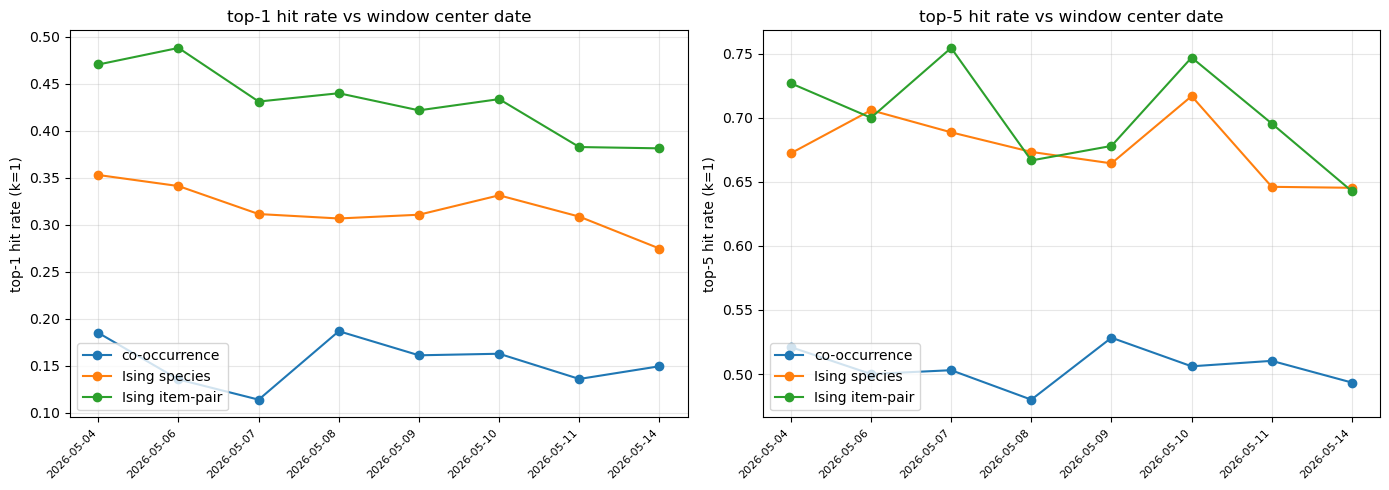

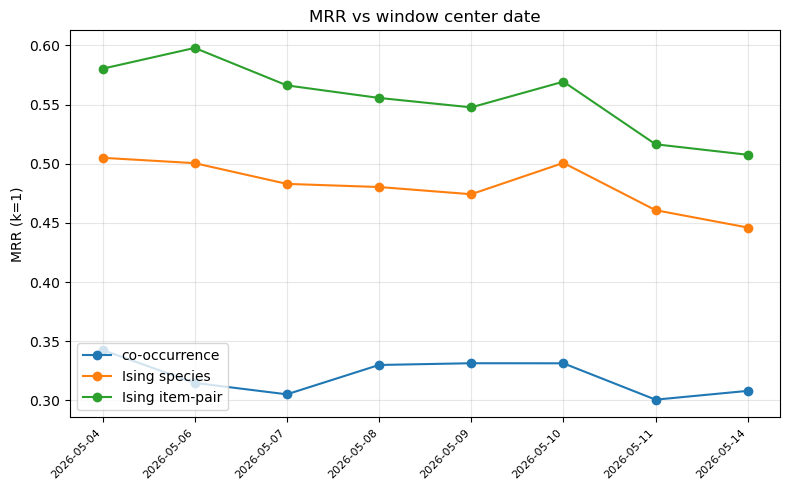

In [22]:
# Drift plots: top-K hit rate and MRR vs window center date.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
x = np.arange(N_WINDOWS)

for ax, K in zip(axes, [1, 5]):
    for name in drift_scorers:
        ax.plot(x, drift_metrics[name]["hit_rate"][K], marker="o", label=name)
    ax.set_xticks(x)
    ax.set_xticklabels(window_dates_center, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(f"top-{K} hit rate (k=1)")
    ax.set_title(f"top-{K} hit rate vs window center date")
    ax.grid(alpha=0.3)
    ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 5))
for name in drift_scorers:
    ax2.plot(x, drift_metrics[name]["mrr"], marker="o", label=name)
ax2.set_xticks(x)
ax2.set_xticklabels(window_dates_center, rotation=45, ha="right", fontsize=8)
ax2.set_ylabel("MRR (k=1)")
ax2.set_title("MRR vs window center date")
ax2.grid(alpha=0.3)
ax2.legend(loc="lower left")
plt.tight_layout()
plt.show()

## Drift interpretation

What the curves typically tell us:

- **All three lines drift downward together**: the meta is genuinely shifting, and *no* fixed model captures the new state. Distance between lines tells you which model degrades fastest.
- **A sharp drop in one window**: candidate for a meta shock — a new team archetype was discovered that hadn't shown up enough in training to register. Cross-reference the dates against community events / format announcements.
- **Ising species drifts faster than Ising item-pair (or vice versa)**: gap-stability tells you which feature granularity is more robust to meta evolution. Item-pair degrading faster would be a memorization signal (more features, less per-feature data, more capacity to overfit to specific roster choices that don't survive). Species degrading faster would mean item-pair is capturing more time-stable structure.
- **All three lines hold roughly flat**: meta is stable across the second half of the corpus and the train-half parameters generalize fine. Less interesting as a result but a useful null — confirms no systematic harness bug producing apparent decay.
- **Co-occurrence drifts least**: counts are robust summary statistics; the Ising models' edge comes from fitting *patterns* that are more sensitive to which patterns happen to be in style. This would suggest the Ising win is more "compression of current meta" than "discovery of timeless structure."

To go further: re-cut the experiment with the train half ending at a *known* event (a major regulation update, a Pokemon Champions patch, a high-profile tournament result going viral) and check whether the drop in the first post-event window is larger than the drift between adjacent windows otherwise. That's the cleanest test of "model detects shock vs. drift."